====valori lipsa in train====

nume                  0
an_lansare            0
gen_principal         0
nr_platforme          0
timp_joc_mediu        0
rating_utilizatori    0
nr_recenzii           0
nr_realizari          0
este_hit              0
dtype: int64
====statistici descriptive====

        an_lansare  nr_platforme  timp_joc_mediu  rating_utilizatori  \
count   611.000000    611.000000      611.000000          611.000000   
mean   2013.119476      4.505728        7.039280            3.801064   
std       4.915395      2.153430        9.718249            0.467643   
min    1994.000000      1.000000        0.000000            2.230000   
25%    2011.000000      3.000000        3.000000            3.530000   
50%    2014.000000      4.000000        5.000000            3.870000   
75%    2017.000000      6.000000        8.000000            4.140000   
max    2023.000000     13.000000      121.000000            4.640000   

       nr_recenzii  nr_realizari    este_hit  
count   611.

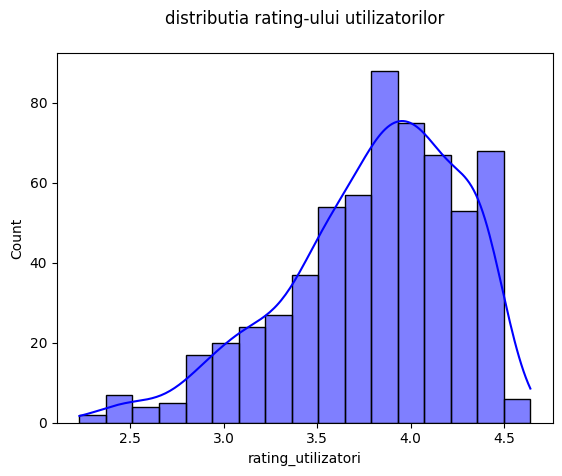

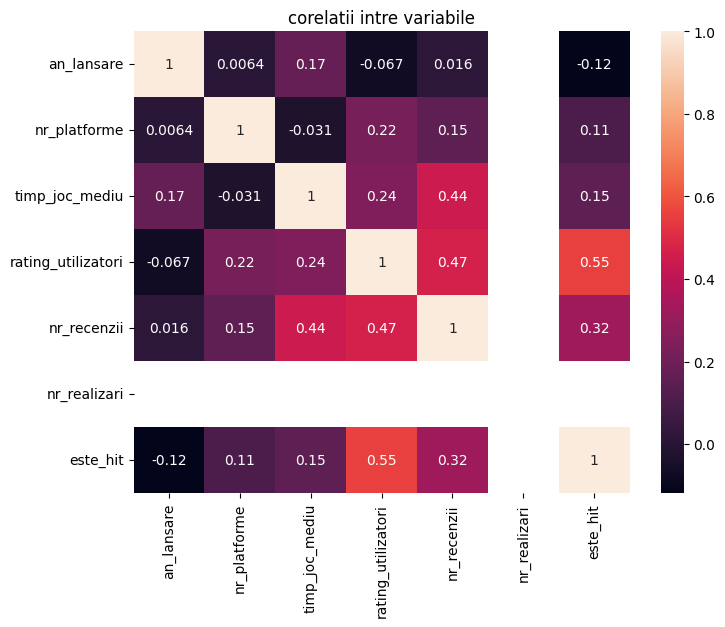

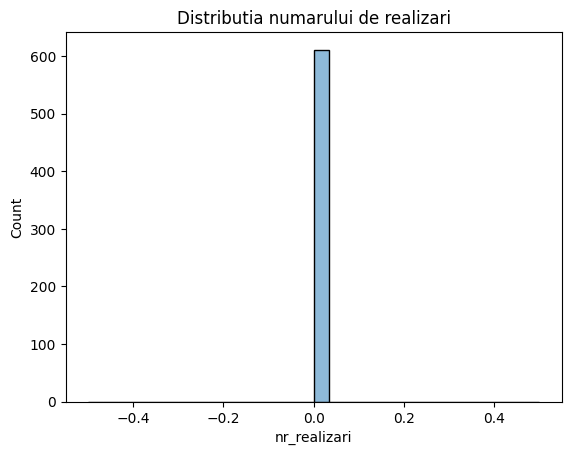

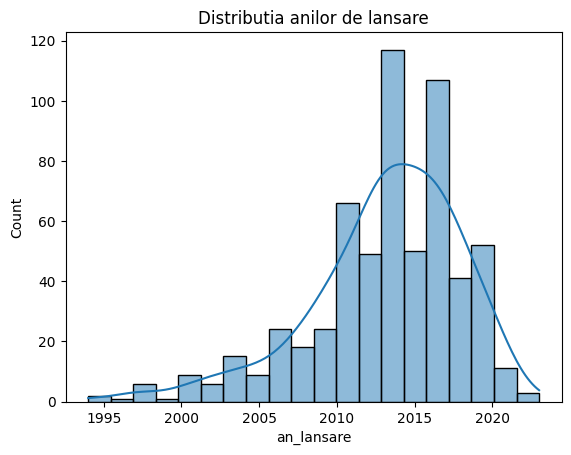

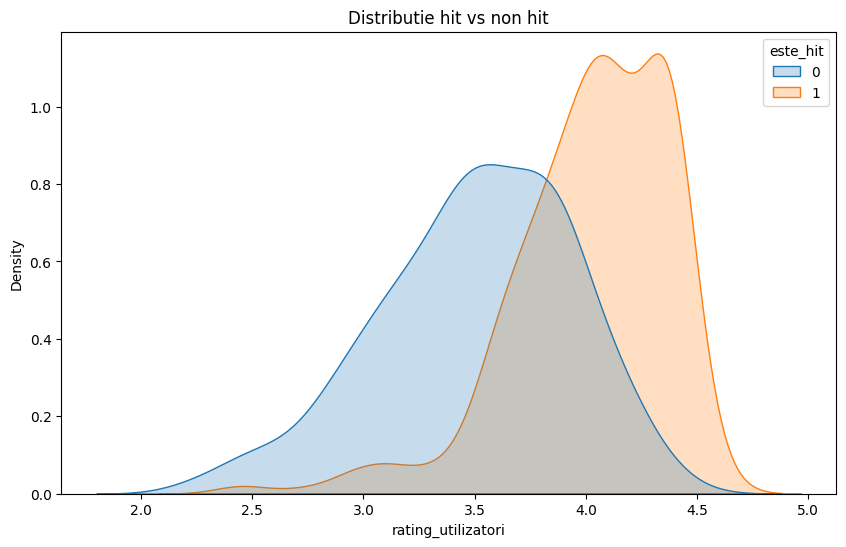

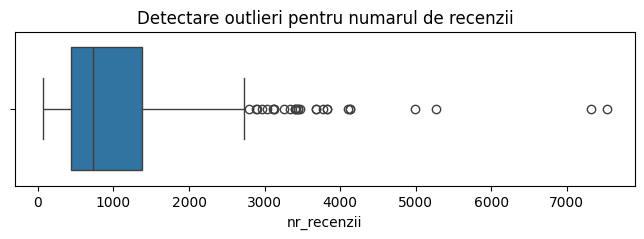

Coloana nr_realizari a fost eliminata cu succes.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#punem datele din fisierele de train si test
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

#afisam primele 5 randuri pentru verificare
df_train.head()

#vedem daca avem date lipsa pt cleaning
print("====valori lipsa in train====\n")
print(df_train.isnull().sum())

#statistici descriptive
print("====statistici descriptive====\n")
print(df_train.describe())

#schimba rating cu numele coloanei daca e in api are alt nume
sns.histplot(df_train['rating_utilizatori'], kde=True, color='blue')
plt.title('distributia rating-ului utilizatorilor\n')
plt.show()

#facem un heatmap pentru corelatii
plt.figure(figsize=(8, 6))
sns.heatmap(df_train.corr(numeric_only=True), annot=True)
plt.title('corelatii intre variabile')
plt.show()

#distributia jocurilor dupa nr de
sns.histplot(df_train['nr_realizari'], bins=30, kde=True)
plt.title('Distributia numarului de realizari')
plt.show()

#histograma pentru cum sunt impartite datele pe ani
sns.histplot(df_train['an_lansare'], bins=20, kde=True)
plt.title('Distributia anilor de lansare')
plt.show()

#facem un hue pentru a separa cei care considera jocul un hit sau nu
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_train, x='rating_utilizatori', hue='este_hit', fill=True, common_norm=False)
plt.title('Distributie hit vs non hit')
plt.show()

#detectam outlierii in recenzii
plt.figure(figsize=(8, 2))
sns.boxplot(x=df_train['nr_recenzii'])
plt.title('Detectare outlieri pentru numarul de recenzii')
plt.show()

#facem data cleaning si stergem coloana de realizari pentru antrenare
df_train = df_train.drop(columns=['nr_realizari'])
df_test = df_test.drop(columns=['nr_realizari'])

==== Performanta modelului ====

Accuracy: 0.80

Raport de clasificare:
              precision    recall  f1-score   support

           0       0.76      0.75      0.76       110
           1       0.82      0.83      0.83       153

    accuracy                           0.80       263
   macro avg       0.79      0.79      0.79       263
weighted avg       0.80      0.80      0.80       263



c:\Users\ilie_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


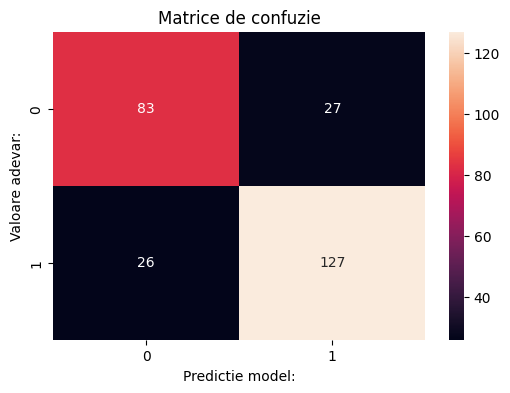

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#scapam de nume deoarece e doar text asa ca nu trebuie analizat
x_train = df_train.drop(columns=['nume', 'este_hit'])
y_train = df_train['este_hit']

x_test = df_test.drop(columns=['nume', 'este_hit'])
y_test = df_test['este_hit']

#facem genul jocului din text in coloana de numere pentru antrenare
x_train = pd.get_dummies(x_train, columns=['gen_principal'])
x_test = pd.get_dummies(x_test, columns=['gen_principal'])

#verificam daca seteul de test si train au acelasi numar de coloane ca sa fie valid
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

#folosim regresie liniara pentru antrenare
regresie_liniara = LogisticRegression(max_iter=1000, random_state=42)
regresie_liniara.fit(x_train, y_train)

#antrenam modelul si ii evaluam accuracy-ul
predictii = regresie_liniara.predict(x_test)
print("==== Performanta modelului ====\n")
print(f"Accuracy: {accuracy_score(y_test, predictii):.2f}\n")
print("Raport de clasificare:")
print(classification_report(y_test, predictii))

#Afisam matricea de confuzie
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, predictii), annot=True, fmt = 'd')
plt.title('Matrice de confuzie')
plt.ylabel('Valoare adevar:')
plt.xlabel('Predictie model:')
plt.show()
